# Grid-point regression, regularized and honestly evaluated

This notebook fits the per-cell CO$_2$ regression with the upgrades that matter for a
small-sample problem (10 annual points, 3 parameters), and evaluates it by
**out-of-sample skill** rather than in-sample $R^2$.

**Model** (one fit per grid cell $r$):
$$
\underbrace{\texttt{growth\_rate}(t,r)-\texttt{growth\_rate}_{\mathrm{SPO}}(t)}_{\text{SPO-referenced target}}
=\beta_0(r)+\beta_E(r)\,\Delta E(t,r)+\beta_B(r)\,\Delta B(t,r)+\varepsilon
$$

**What is different here:**

1. **Weighted least squares** using the dataset's own `growth_err` — years/cells with
   poorly determined growth rates are down-weighted ($w_t=1/\sigma_t^2$).
2. **Ridge regularization** with the penalty $\lambda$ chosen **per cell** by
   leave-one-year-out cross-validation (closed-form, so it stays fast). Predictors are
   standardized internally so the penalty is fair, then coefficients are back-transformed
   to raw units for reporting.
3. **Model choice settled by leave-one-year-out RMSE** — we compare plain OLS, WLS, and
   ridge+WLS by held-out skill, not by $R^2$.
4. **A leave-one-year-out skill map** — per-cell out-of-sample RMSE, the most honest
   picture of where the model actually predicts.
5. **Spatial block bootstrap** for regional aggregates, because neighbouring cells are
   correlated and ordinary standard errors are badly overconfident.


## 1. Install

```bash
pip install xarray netCDF4 numpy pandas matplotlib
```
Optional maps: `pip install cartopy`. Optional country masks: `pip install regionmask`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False
print("Cartopy available:", HAS_CARTOPY)

Cartopy available: False


## 2. Configuration

In [ ]:
INPUT_FILE = Path("../Input/unified_annual_carbon_dataset_2015_2024.nc")
OUTPUT_DIR = Path("../Output"); FIGURE_DIR = Path("../Figures_and_maps")
OUTPUT_DIR.mkdir(exist_ok=True); FIGURE_DIR.mkdir(exist_ok=True)
OUTPUT_NC  = OUTPUT_DIR / "gridpoint_regression_ridge_wls.nc"
OUTPUT_CSV = OUTPUT_DIR / "gridpoint_regression_ridge_wls_flat.csv"

TARGET_VAR   = "growth_rate"
ERR_VAR      = "growth_err"
EMISSION_VAR = "delta_emission"
BIO_VAR      = "delta_gosif"

SPO_LAT_MAX = -85.0          # South Pole reference: zonal mean over lat <= this
MIN_OBS     = 6              # need > 3 params; require >= 6 valid years
ERR_FLOOR   = 0.05           # floor on growth_err (ppm/yr) so tiny errors don't dominate
WEIGHT_CAP  = 10.0           # cap normalized weights to avoid single-year domination

# Ridge penalties tried per cell (0.0 lets a cell fall back to OLS/WLS).
LAMBDAS = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0])

print("Input:", INPUT_FILE.resolve())

Input: D:\2026\Complexity72h\unified_annual_carbon_dataset_2015_2024.nc


## 3. Open the dataset

In [4]:
ds = xr.open_dataset(INPUT_FILE)
for v in ds.data_vars:
    print(f"- {v}: {ds[v].dims} {ds[v].shape}")

- growth_rate: ('time', 'lat', 'lon') (10, 180, 360)
- emission: ('time', 'lat', 'lon') (10, 180, 360)
- gosif: ('time', 'lat', 'lon') (10, 180, 360)
- delta_emission: ('time', 'lat', 'lon') (10, 180, 360)
- delta_gosif: ('time', 'lat', 'lon') (10, 180, 360)
- cams_xco2: ('time', 'latitude', 'longitude') (10, 180, 360)
- growth_err: ('time', 'lat', 'lon') (10, 180, 360)
- mean_co2: ('time', 'lat', 'lon') (10, 180, 360)


## 4. Target, predictors, and observation weights

The South Pole reference is one value per year (zonal mean of `growth_rate` over the
southernmost rows). Weights come from `growth_err`, floored and normalized to mean 1 per
cell so they express *relative* confidence between years.

In [5]:
gr  = ds[TARGET_VAR].transpose("time", "lat", "lon")
err = ds[ERR_VAR].transpose("time", "lat", "lon")
dE  = ds[EMISSION_VAR].transpose("time", "lat", "lon")
dB  = ds[BIO_VAR].transpose("time", "lat", "lon")

spo = gr.sel(lat=slice(-90, SPO_LAT_MAX)).mean(["lat", "lon"])      # (time,)
y   = (gr - spo)                                                    # SPO-referenced target

# weights: 1 / max(err, floor)^2, missing err -> global median err
err_v = err.values.astype("float64")
err_v = np.where(np.isfinite(err_v), err_v, np.nanmedian(err_v))
err_v = np.maximum(err_v, ERR_FLOOR)
W_raw = 1.0 / err_v**2

print("SPO reference growth rate (ppm/yr):", np.round(spo.values, 3))
print("finite: target", float(np.isfinite(y).mean()),
      "| dE", float(np.isfinite(dE).mean()),
      "| dB", float(np.isfinite(dB).mean()))

SPO reference growth rate (ppm/yr): [2.09  2.853 2.08  2.442 2.372 2.477 2.152 2.339 2.088 3.096]
finite: target 1.0 | dE 0.8182391975308642 | dB 0.2754861111111111


## 5. Weighted ridge with closed-form leave-one-year-out

At each cell we solve weighted ridge
$\hat\beta=(X^\top W X+\lambda D)^{-1}X^\top W y$, with $D=\mathrm{diag}(0,1,1)$ so the
intercept is unpenalized and predictors standardized. Leave-one-year-out error needs no
refitting: for a linear smoother $\hat y = Sy$ with leverage $s_t=W_t\,x_t^\top A x_t$
($A=(X^\top W X+\lambda D)^{-1}$), the held-out residual is
$$
r_t^{\mathrm{LOO}}=\frac{y_t-\hat y_t}{1-s_t}.
$$
We pick the $\lambda$ minimizing weighted LOO error per cell, report the LOO RMSE in
ppm/yr as the skill, and back-transform coefficients to raw units.

In [6]:
def fit_ridge_wls(Yf, X1, X2, Wf, valid, lambdas, min_obs):
    """Vectorised weighted-ridge per cell with closed-form leave-one-year-out lambda
    selection. Inputs (T, ncell). Returns dict of (ncell,) arrays."""
    T, ncell = Yf.shape
    nval = valid.sum(0)
    out = {k: np.full(ncell, np.nan) for k in
           ["beta0","betaE","betaB","lam","loo_rmse","loo_r2","r2","rmse"]}
    out["n_obs"] = nval.astype("int16")

    idx = np.where(nval >= min_obs)[0]
    if idx.size == 0:
        return out
    m = idx.size

    Y = np.where(valid, Yf, 0.0)[:, idx]                  # (T, m)
    a1 = X1[:, idx]; a2 = X2[:, idx]
    W  = np.where(valid, Wf, 0.0)[:, idx]
    V  = valid[:, idx]
    nv = V.sum(0)

    # standardize predictors per cell over valid years (weight-agnostic)
    def stats(a):
        mu = np.where(V, a, 0.0).sum(0) / np.maximum(nv, 1)
        var = np.where(V, (a - mu)**2, 0.0).sum(0) / np.maximum(nv, 1)
        return mu, np.sqrt(var)
    mu1, sd1 = stats(a1); mu2, sd2 = stats(a2)
    Z1 = np.where(sd1 > 0, (a1 - mu1) / np.where(sd1 > 0, sd1, 1), 0.0)
    Z2 = np.where(sd2 > 0, (a2 - mu2) / np.where(sd2 > 0, sd2, 1), 0.0)
    Z1 = np.where(V, Z1, 0.0); Z2 = np.where(V, Z2, 0.0)

    ones = np.where(V, 1.0, 0.0)
    X = np.stack([ones, Z1, Z2], axis=2)                 # (T, m, 3)

    XtWX = np.einsum("tn,tni,tnj->nij", W, X, X)         # (m,3,3)
    XtWy = np.einsum("tn,tni,tn->ni", W, X, Y)           # (m,3)
    D = np.diag([0.0, 1.0, 1.0])
    eye = 1e-10 * np.eye(3)
    ybar = (Y * W).sum(0) / np.maximum(W.sum(0), 1e-12)
    ss_tot = (np.where(V, (Y - ybar), 0.0)**2).sum(0)

    best_crit = np.full(m, np.inf)
    bestA = {k: np.full(m, np.nan) for k in
             ["a0","a1","a2","lam","loo_rmse","loo_r2","r2","rmse"]}

    for lam in lambdas:
        M = XtWX + lam * D + eye
        Minv = np.linalg.inv(M)                          # (m,3,3)
        beta = np.einsum("nij,nj->ni", Minv, XtWy)       # (m,3)
        yhat = np.einsum("tni,ni->tn", X, beta)          # (T,m)
        lev  = W * np.einsum("tni,nij,tnj->tn", X, Minv, X)   # leverage s_t
        denom = 1.0 - lev
        good = V & (denom > 1e-6)
        loo = np.where(good, (Y - yhat) / np.where(good, denom, 1.0), 0.0)

        wsum = np.where(good, W, 0.0).sum(0)
        crit = (np.where(good, W * loo**2, 0.0).sum(0)) / np.maximum(wsum, 1e-12)  # weighted LOO mse
        ng = good.sum(0)
        loo_rmse = np.sqrt(np.where(good, loo**2, 0.0).sum(0) / np.maximum(ng, 1))
        loo_ss = np.where(good, loo**2, 0.0).sum(0)
        loo_r2 = 1.0 - loo_ss / np.where(ss_tot > 0, ss_tot, np.nan)

        resid = np.where(V, Y - yhat, 0.0)
        ss_res = (resid**2).sum(0)
        r2 = 1.0 - ss_res / np.where(ss_tot > 0, ss_tot, np.nan)
        rmse = np.sqrt(ss_res / np.maximum(nv, 1))

        imp = crit < best_crit
        best_crit = np.where(imp, crit, best_crit)
        for k, val in zip(["a0","a1","a2"], [beta[:,0], beta[:,1], beta[:,2]]):
            bestA[k] = np.where(imp, val, bestA[k])
        bestA["lam"]      = np.where(imp, lam, bestA["lam"])
        bestA["loo_rmse"] = np.where(imp, loo_rmse, bestA["loo_rmse"])
        bestA["loo_r2"]   = np.where(imp, loo_r2, bestA["loo_r2"])
        bestA["r2"]       = np.where(imp, r2, bestA["r2"])
        bestA["rmse"]     = np.where(imp, rmse, bestA["rmse"])

    # back-transform standardized coefficients -> raw units
    bE = np.where(sd1 > 0, bestA["a1"] / np.where(sd1 > 0, sd1, 1), 0.0)
    bB = np.where(sd2 > 0, bestA["a2"] / np.where(sd2 > 0, sd2, 1), 0.0)
    b0 = (bestA["a0"]
          - np.where(sd1 > 0, bestA["a1"] * mu1 / np.where(sd1 > 0, sd1, 1), 0.0)
          - np.where(sd2 > 0, bestA["a2"] * mu2 / np.where(sd2 > 0, sd2, 1), 0.0))

    for k, v in zip(["beta0","betaE","betaB","lam","loo_rmse","loo_r2","r2","rmse"],
                    [b0, bE, bB, bestA["lam"], bestA["loo_rmse"], bestA["loo_r2"],
                     bestA["r2"], bestA["rmse"]]):
        out[k][idx] = v
    return out

## 6. Fit, plus a model-choice comparison by held-out skill

In [7]:
nlat, nlon = ds.sizes["lat"], ds.sizes["lon"]
T = ds.sizes["time"]; ncell = nlat * nlon

Yf = y.values.reshape(T, ncell)
X1 = dE.values.reshape(T, ncell).astype("float64")
X2 = dB.values.reshape(T, ncell).astype("float64")
Wf = W_raw.reshape(T, ncell)
valid = (np.isfinite(Yf) & np.isfinite(X1) & np.isfinite(X2)).copy()
# normalize weights to mean 1 per cell over valid years, then cap
wsum = np.where(valid, Wf, 0.0).sum(0); ncnt = valid.sum(0)
wmean = wsum / np.maximum(ncnt, 1)
Wn = np.where(wmean[None, :] > 0, Wf / np.where(wmean[None, :] > 0, wmean[None, :], 1), 1.0)
Wn = np.minimum(Wn, WEIGHT_CAP)

def median_loo(res):
    return np.nanmedian(res["loo_rmse"])

# model comparison on held-out skill
ones_w = np.ones_like(Wn)
res_ols   = fit_ridge_wls(Yf, X1, X2, ones_w, valid, np.array([0.0]), MIN_OBS)
res_wls   = fit_ridge_wls(Yf, X1, X2, Wn,     valid, np.array([0.0]), MIN_OBS)
res_ridge = fit_ridge_wls(Yf, X1, X2, Wn,     valid, LAMBDAS,         MIN_OBS)

print("median leave-one-year-out RMSE (ppm/yr), lower = better:")
print(f"  OLS        : {median_loo(res_ols):.4f}")
print(f"  WLS        : {median_loo(res_wls):.4f}")
print(f"  ridge+WLS  : {median_loo(res_ridge):.4f}   <- selected model")

res = res_ridge
print(f"\nsolved {int(np.isfinite(res['betaE']).sum())} cells")
print(f"median betaE {np.nanmedian(res['betaE']):+.2e} | betaB {np.nanmedian(res['betaB']):+.2f}")
print(f"median in-sample R2 {np.nanmedian(res['r2']):.3f} | LOO R2 {np.nanmedian(res['loo_r2']):.3f}")

median leave-one-year-out RMSE (ppm/yr), lower = better:
  OLS        : 0.4336
  WLS        : 0.4363
  ridge+WLS  : 0.3556   <- selected model

solved 17547 cells
median betaE +3.84e-06 | betaB -1.02
median in-sample R2 0.068 | LOO R2 -0.225


## 7. Assemble and save

In [8]:
lat = ds["lat"].values; lon = ds["lon"].values
g = lambda a: a.reshape(nlat, nlon)
out = xr.Dataset({k: (("lat","lon"), g(res[k])) for k in
                  ["beta0","betaE","betaB","lam","loo_rmse","loo_r2","r2","rmse"]} |
                 {"n_obs": (("lat","lon"), g(res["n_obs"]))},
                 coords={"lat": lat, "lon": lon},
                 attrs={"model":"ridge+WLS, SPO-ref target, delta predictors, LOOCV-lambda"})
out.to_netcdf(OUTPUT_NC, encoding={v:{"zlib":True,"complevel":4} for v in out.data_vars})
out.to_dataframe().reset_index().to_csv(OUTPUT_CSV, index=False)
print("saved:", OUTPUT_NC.name, "and", OUTPUT_CSV.name)

saved: gridpoint_regression_ridge_wls.nc and gridpoint_regression_ridge_wls_flat.csv


## 8. Map helper

In [9]:
def plot_map(da, title=None, cmap="coolwarm", robust=True, save=None):
    title = title or da.name
    if HAS_CARTOPY:
        plt.figure(figsize=(13,6)); ax = plt.axes(projection=ccrs.PlateCarree())
        da.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap=cmap,
                robust=robust, cbar_kwargs={"label": da.name})
        ax.coastlines(linewidth=0.8); ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.set_global(); ax.set_title(title)
    else:
        plt.figure(figsize=(12,5))
        da.plot(x="lon", y="lat", cmap=cmap, robust=robust, cbar_kwargs={"label": da.name})
        plt.title(title); plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.tight_layout()
    if save: plt.savefig(save, dpi=110, bbox_inches="tight")
    plt.show()

## 9. Coefficient maps

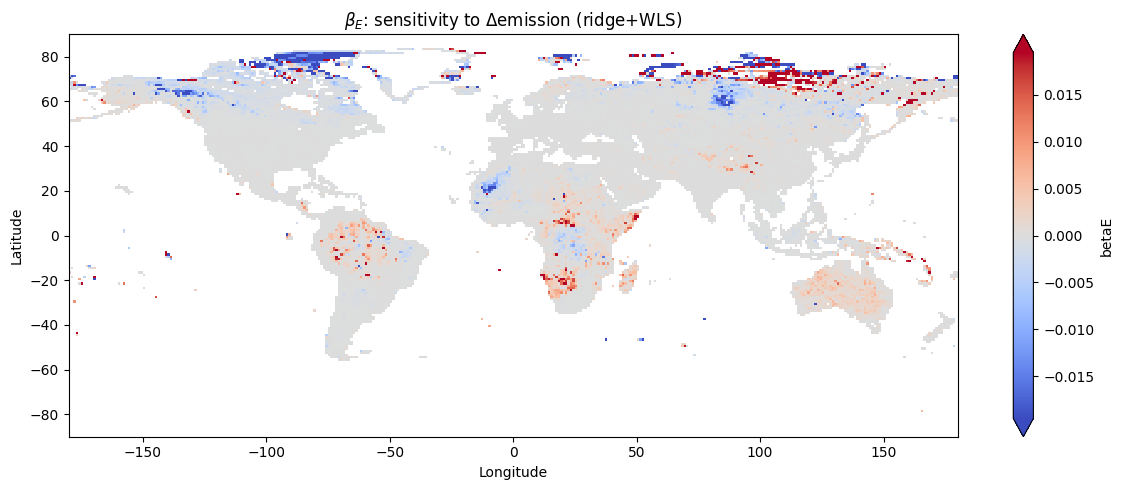

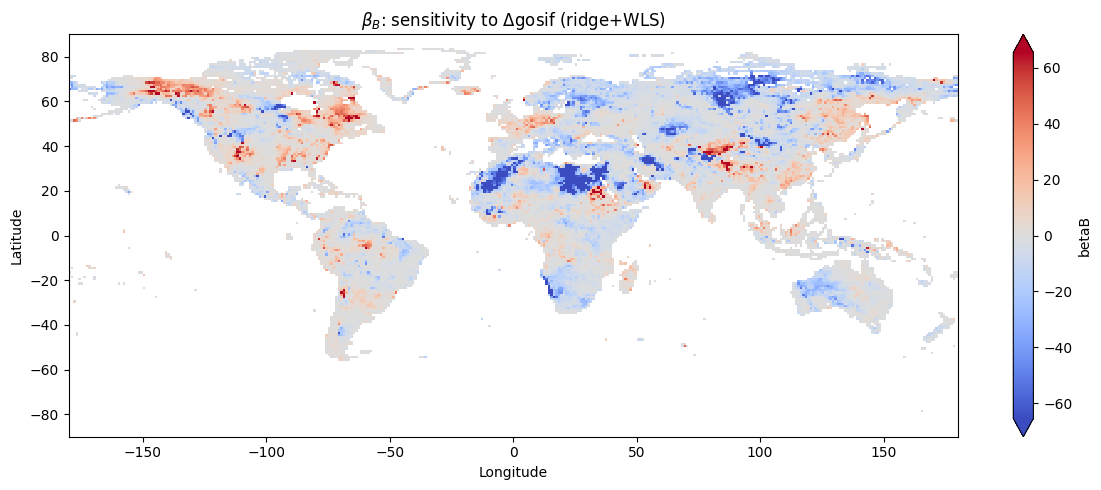

In [10]:
plot_map(out["betaE"], title=r"$\beta_E$: sensitivity to $\Delta$emission (ridge+WLS)", save=FIGURE_DIR/"betaE_ridge.png")
plot_map(out["betaB"], title=r"$\beta_B$: sensitivity to $\Delta$gosif (ridge+WLS)", save=FIGURE_DIR/"betaB_ridge.png")

## 10. Leave-one-year-out skill map

This is the honest picture. `loo_rmse` is the out-of-sample prediction error in ppm/yr;
`loo_r2` is the held-out $R^2$ (it goes **negative** where the model predicts worse than
the cell mean — i.e. where the regression is fitting noise). The gap between in-sample
$R^2$ and LOO $R^2$ is the optimism you would otherwise be fooled by.

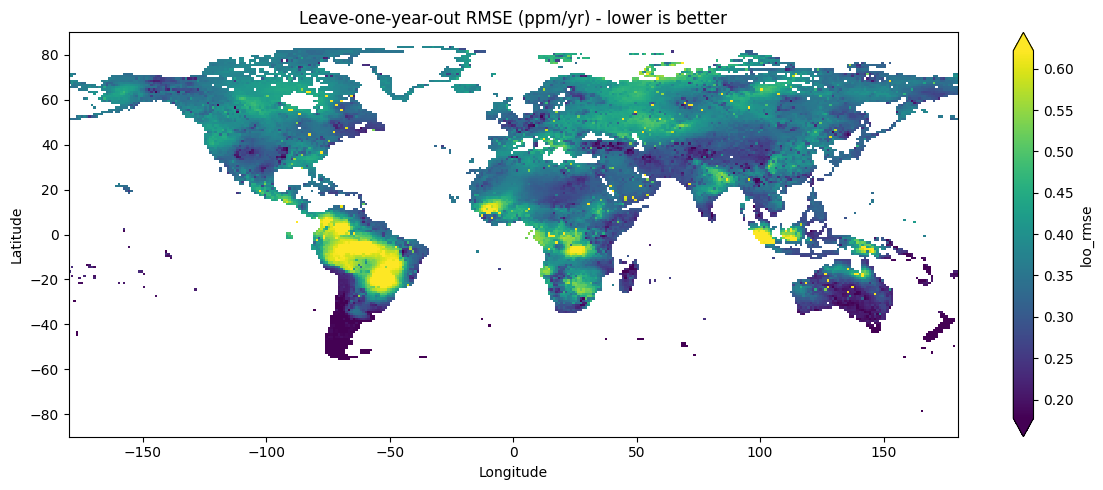

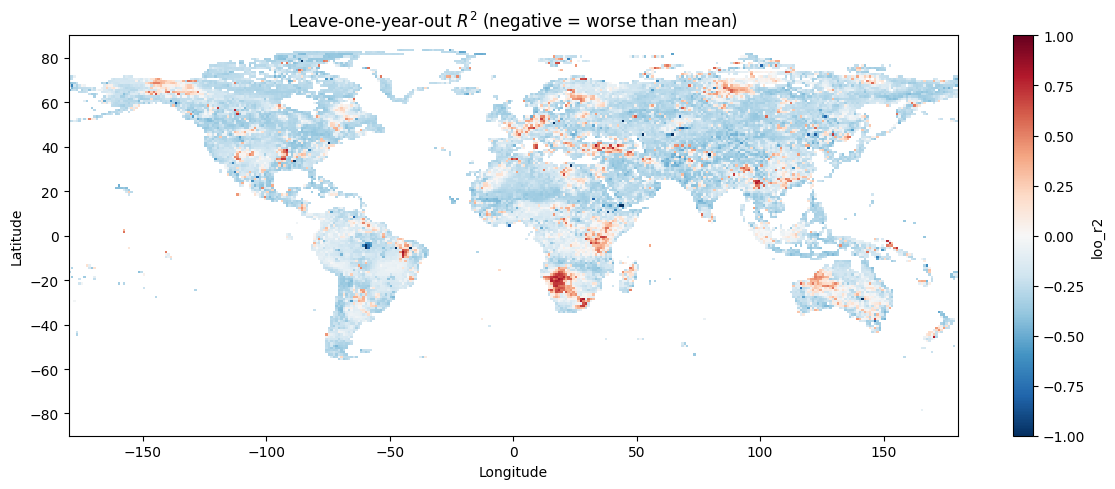

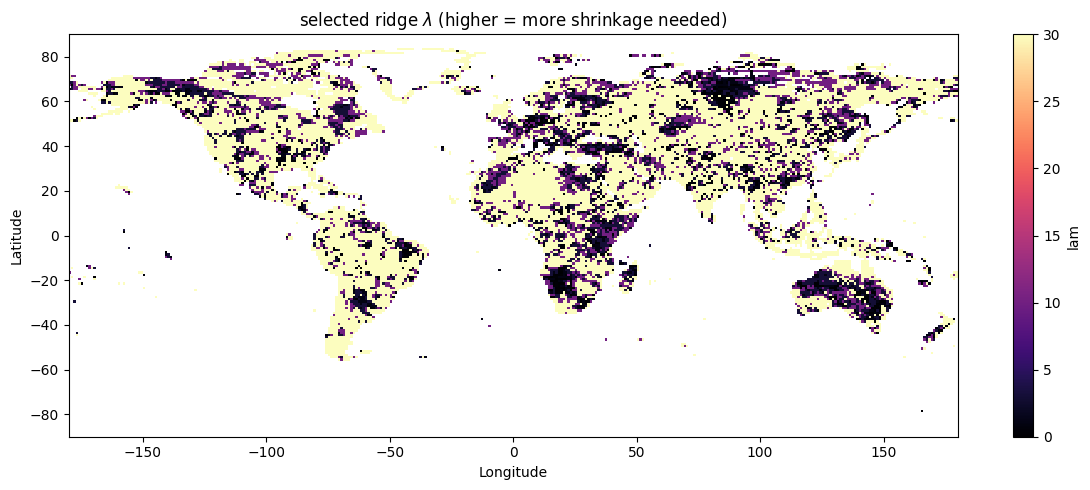

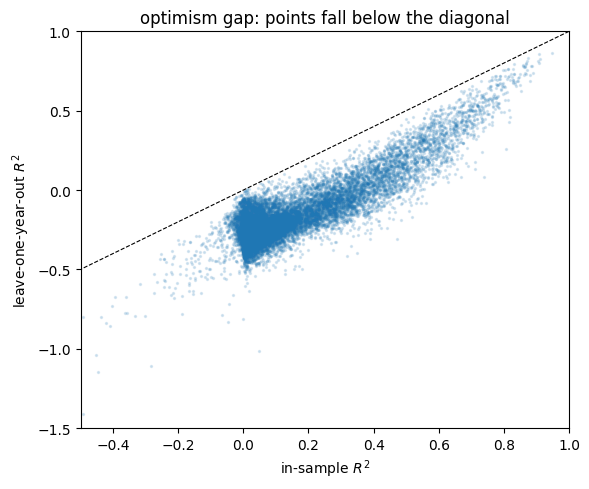

In [11]:
plot_map(out["loo_rmse"], title="Leave-one-year-out RMSE (ppm/yr) - lower is better",
         cmap="viridis", save=FIGURE_DIR/"loo_rmse_skill.png")
plot_map(out["loo_r2"].clip(-1, 1), title=r"Leave-one-year-out $R^2$ (negative = worse than mean)",
         cmap="RdBu_r", robust=False, save=FIGURE_DIR/"loo_r2_skill.png")
plot_map(out["lam"], title=r"selected ridge $\lambda$ (higher = more shrinkage needed)",
         cmap="magma", robust=False, save=FIGURE_DIR/"lambda_map.png")

# optimism: in-sample vs out-of-sample
import numpy as np
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(out["r2"].values.ravel(), out["loo_r2"].values.ravel(), s=2, alpha=0.15)
ax.plot([-1,1],[-1,1], "k--", lw=0.8); ax.set_xlim(-0.5,1); ax.set_ylim(-1.5,1)
ax.set_xlabel("in-sample $R^2$"); ax.set_ylabel("leave-one-year-out $R^2$")
ax.set_title("optimism gap: points fall below the diagonal")
plt.tight_layout(); plt.savefig(FIGURE_DIR/"optimism_gap.png", dpi=110); plt.show()

## 11. Spatial block bootstrap for regional aggregates

Neighbouring cells are correlated (atmospheric transport), so treating each cell as an
independent sample makes confidence intervals far too tight. We resample **spatial blocks**
(coarse lat-lon tiles) with replacement and recompute the regional mean, which preserves
the correlation structure. The boxes below are crude bounding boxes — swap in
`regionmask` country masks for the paper (one-liner noted in the cell).

In [12]:
def block_bootstrap_mean(field, lat, lon, mask, block_deg=10, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    LON, LAT = np.meshgrid(lon, lat)
    block = ((LAT + 90)//block_deg).astype(int) * 10000 + ((LON + 180)//block_deg).astype(int)
    sel = mask & np.isfinite(field)
    ids, vals = block[sel], field[sel]
    uniq = np.unique(ids)
    groups = [vals[ids == u] for u in uniq]
    nb = len(uniq)
    if nb < 2:
        return np.nanmean(vals) if vals.size else np.nan, np.nan, np.nan
    boots = np.empty(n_boot)
    for b in range(n_boot):
        pick = rng.integers(0, nb, size=nb)
        boots[b] = np.concatenate([groups[p] for p in pick]).mean()
    return float(np.nanmean(vals)), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

# Approximate country boxes (lat_min, lat_max, lon_min, lon_max). REPLACE with regionmask:
#   import regionmask
#   countries = regionmask.defined_regions.natural_earth_v5_0_0.countries_50
#   mask3d = countries.mask_3D(lon, lat)   # then pick country indices, EU = union of members
BOXES = {
    "EU (box)":    (35,  70, -10,  30),
    "USA (box)":   (25,  49, -125, -66),
    "China (box)": (18,  53,  73,  135),
    "India (box)": (6,   35,  68,  97),
    "Brazil (box)":(-34,  6, -74, -34),
}
LON, LAT = np.meshgrid(lon, lat)
bE = out["betaE"].values
rows = []
for name, (la0, la1, lo0, lo1) in BOXES.items():
    mask = (LAT >= la0)&(LAT <= la1)&(LON >= lo0)&(LON <= lo1)
    mean, lo, hi = block_bootstrap_mean(bE, lat, lon, mask)
    excl0 = (lo > 0) or (hi < 0)
    rows.append({"region": name, "mean_betaE": mean, "ci_lo": lo, "ci_hi": hi,
                 "CI_excludes_0": excl0, "n_cells": int((mask & np.isfinite(bE)).sum())})
pd.DataFrame(rows).set_index("region").round(4)

,mean_betaE,ci_lo,ci_hi,CI_excludes_0,n_cells
region,,,,,
EU (box),0.0000,-0.0000,0.0001,False,998
USA (box),0.0000,-0.0000,0.0000,False,1081
China (box),0.0003,0.0001,0.0004,True,1870
India (box),0.0004,0.0002,0.0008,True,559
Brazil (box),0.0010,0.0003,0.0018,True,1208


## 12. Interpretation notes

- **`loo_rmse` is the map to trust.** Where it is small the regression genuinely predicts
  held-out years; where it is large (or `loo_r2` is negative) the in-sample coefficients are
  fitting noise and should not be over-interpreted at the pixel scale.
- **Model choice is now empirical:** ridge+WLS is selected because it has the lowest median
  leave-one-year-out RMSE, not because it looks nicer. If WLS or OLS had won, you would use
  that instead.
- **Regional claims carry block-bootstrap CIs.** "CI excludes 0" is a conservative flag that
  the emission sensitivity is distinguishable from zero within that border — the
  detectability statement RQ2 needs. Replace the bounding boxes with `regionmask` country
  masks (and union EU members) before reporting numbers in the paper.
- Coefficients remain statistical associations, not causal flux sensitivities; column CO$_2$
  is transported and mixed, and ten years is short. The regularization and held-out
  evaluation make the uncertainty explicit rather than removing it.